In [15]:
import tomllib
import pandas as pd
import osmnx as osm
import geopandas as gpd
import pycountry 
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

with open("config.toml", "rb") as f:
    config = tomllib.load(f)

In [9]:

def read_admin(path_admin,adl):
    adms=gpd.read_file(path_admin, layer=f"ADM_{adl}")
    
    adms = adms.rename(columns={'GID_0': 'iso3'})
    iso3_mapping = {'Z01':'IND', 'Z02':'CHN', 'Z03':'CHN', 'Z04':'IND', 'Z05':'IND', 'Z06':'PAK', 'Z07':'IND', 'Z08':'CHN', 'Z09':'IND'}
    adms["iso3"] = adms["iso3"].replace(iso3_mapping)
    adms = adms[~adms["iso3"].isin(["XKO",None])]
    pyi3=[pycountry.countries.get(alpha_3=i3) for i3 in adms.iso3]
    adms=adms[[x is not None for x in pyi3]] # som admin2 will be deleted belonging to ['China', 'India', 'Pakistan', 'Kosovo'] as they are in conflicted areas
    adms["iso2"]=[pycountry.countries.get(alpha_3=i3).alpha_2 for i3 in adms.iso3]

    adms["ADMIN0"]=adms["COUNTRY"]
    if adl ==1:
        adms["ADMIN1"]=adms["NAME_1"]
    elif adl ==2:
        adms["ADMIN1"]=adms["NAME_1"]
        adms["ADMIN2"]=adms["NAME_2"]
    
    
    return adms


In [20]:
input_emdat = pd.read_csv("/eos/jeodpp/home/users/roncmic/data/GeoLocDisExp/input_emdat.csv")

In [3]:
dataframes = []

for i in range(1, 6):  
    file_path = f"/eos/jeodpp/home/users/roncmic/data/GeoLocDisExp/results/LLMGeoDis_part{i}.csv"
    df = pd.read_csv(file_path)
    dataframes.append(df)

llmgeodis = pd.concat(dataframes, ignore_index=True)

In [12]:
gadm1 = read_admin(config["geocoding"]["gadm_path"], 1)


In [14]:
counts = llmgeodis['DisNo.'].value_counts().reset_index()
counts.columns = ['DisNo.', 'Count']

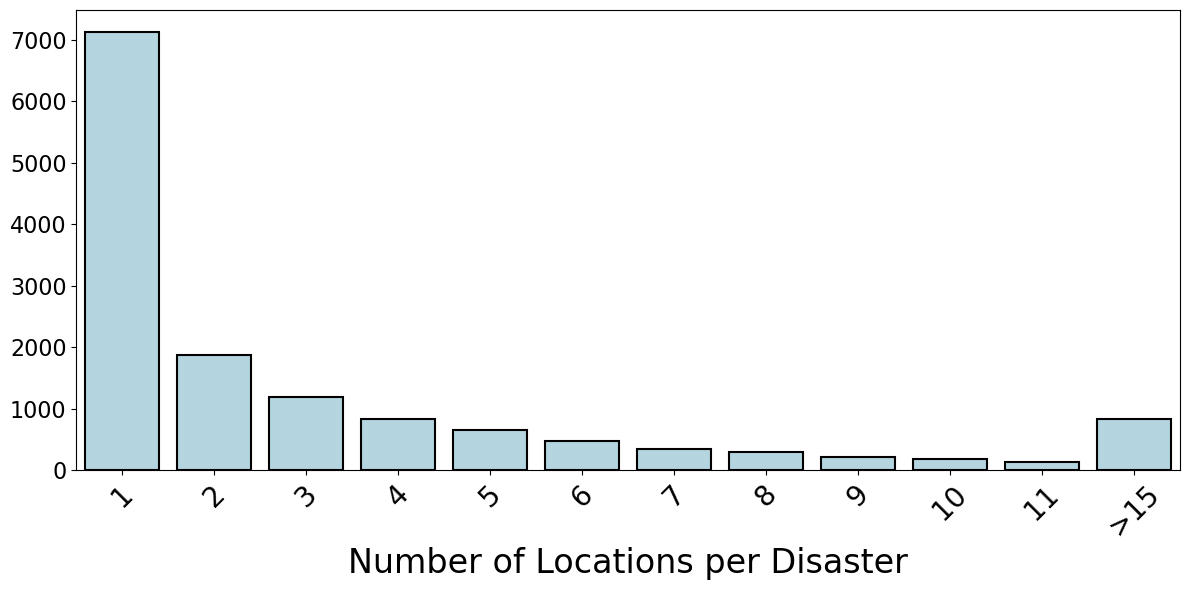

In [17]:
bins = list(range(1, 13))  
if counts['Count'].max() > 15:
    bins.append(counts['Count'].max() + 1) 

labels = list(range(1, 13))
if counts['Count'].max() > 15:
    labels[-1] = '>15'  
    
counts['Count Interval'] = pd.cut(
    counts['Count'],
    bins=bins,
    labels=labels,
    right=False,        
    include_lowest=True
)

count_distribution = counts['Count Interval'].value_counts().reset_index()
count_distribution.columns = ['Count Interval', 'Frequency']

def sort_key(x):
    try:
        return int(x)
    except ValueError:
        return 16  # '>30'

count_distribution['Count Interval'] = count_distribution['Count Interval'].astype(str)
count_distribution = count_distribution.sort_values(by='Count Interval', key=lambda x: x.map(sort_key))

plt.figure(figsize=(12, 6))
sns.barplot(x='Count Interval', y='Frequency', data=count_distribution, color='lightblue', edgecolor='black', linewidth=1.5)
plt.xlabel('Number of Locations per Disaster', fontsize=24)
plt.ylabel('', fontsize=14, weight='bold')
plt.xticks(fontsize=20, rotation=45)
plt.yticks(fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


In [24]:
rel = pd.read_csv("/eos/jeodpp/home/users/roncmic/data/GeoLocDisExp/reliability_db.csv")

In [25]:
rel = rel.merge(input_emdat, on="DisNo.")

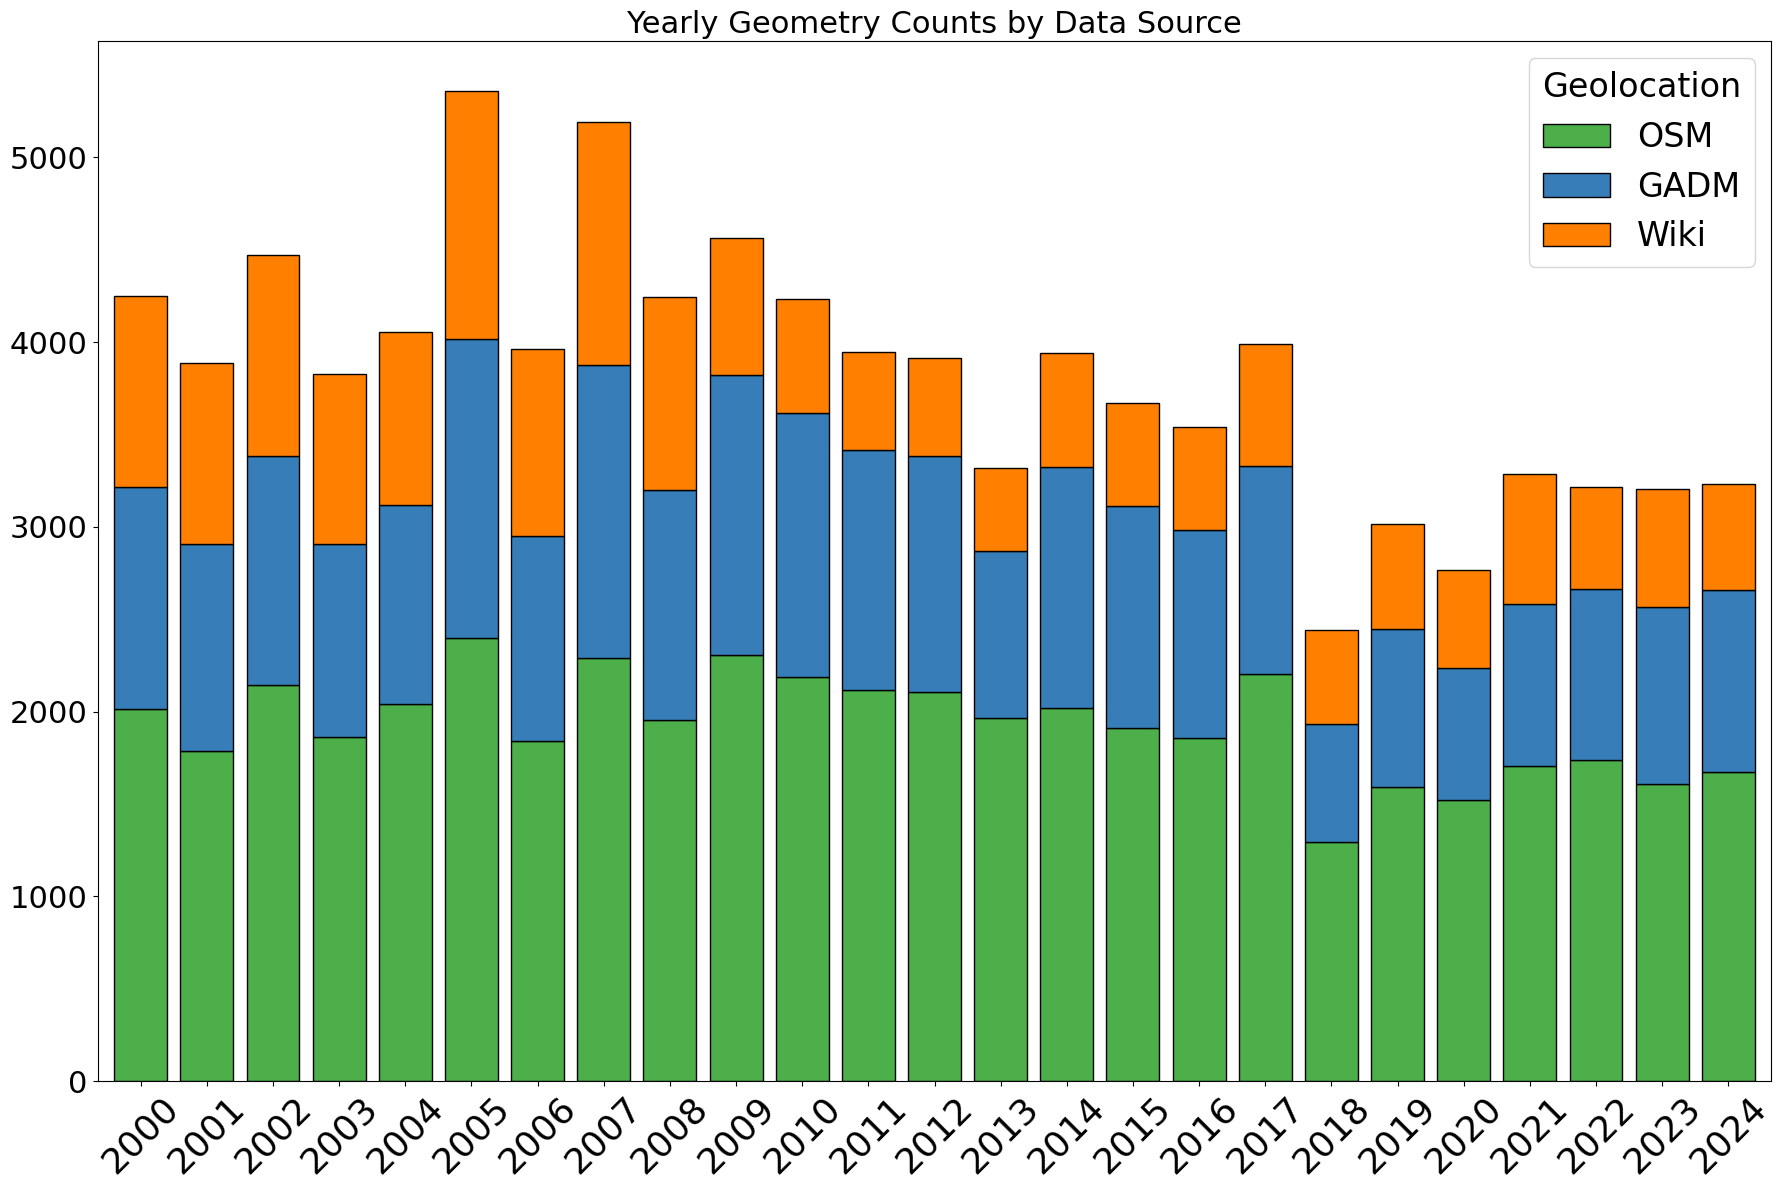

In [26]:
yearly_counts = rel.groupby('Start Year').sum(numeric_only=True)

plt.figure(figsize=(18, 12))
colors = ["#4daf4a", "#377eb8", "#ff7f00"] 

yearly_counts[['osm_count', 'gadm_count', 'wiki_count']].plot(
    kind='bar', stacked=True, color=colors, width=0.8, edgecolor='black', ax=plt.gca()
)

plt.xticks(rotation=45, fontsize=26)
plt.yticks(fontsize=22)
plt.legend(['OSM', 'GADM', 'Wiki'], title='Geolocation', fontsize=24, title_fontsize=24, loc='upper right')
plt.title('Yearly Geometry Counts by Data Source', fontsize=22)
plt.xlabel('')
plt.savefig("Yearly_Geometry_Counts.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

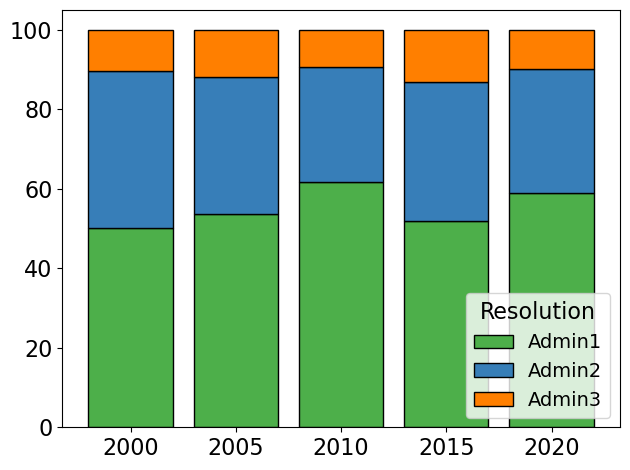

In [27]:
df = rel.copy() 
df['YearBin'] = (df['Start Year'] // 5) * 5  # 5-year bins, e.g., 2000–2004 -> 2000

agg = df.groupby(['YearBin', 'admin_level']).size().reset_index(name='count')
pivot = agg.pivot(index='YearBin', columns='admin_level', values='count').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct[['Admin1', 'Admin2', 'Admin3']]

plt.figure(figsize=(12,7))
colors = ["#4daf4a", "#377eb8", "#ff7f00", "#984ea3"]  

pivot_pct.plot(kind='bar', stacked=True, color=colors, width=0.8, edgecolor='black')

plt.ylabel("")
plt.xlabel("")
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title='Resolution', fontsize=14, title_fontsize=16, loc='lower right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

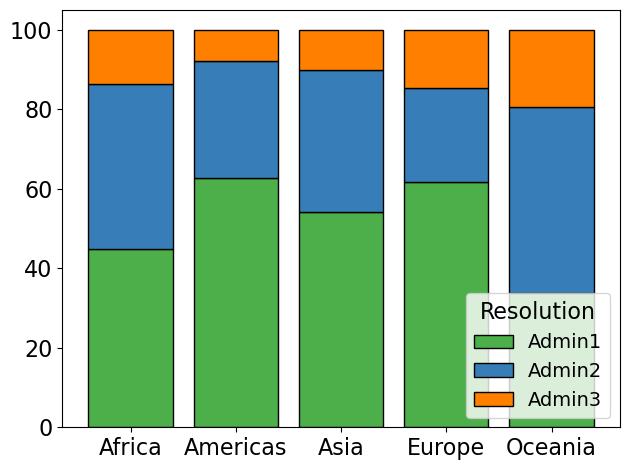

In [28]:
agg_region = df.groupby(['Region', 'admin_level']).size().reset_index(name='count')
pivot_region = agg_region.pivot(index='Region', columns='admin_level', values='count').fillna(0)
pivot_pct_region = pivot_region.div(pivot_region.sum(axis=1), axis=0) * 100
pivot_pct_region = pivot_pct_region[['Admin1', 'Admin2', 'Admin3']]
plt.figure(figsize=(10,6))
colors = ["#4daf4a", "#377eb8", "#ff7f00", "#984ea3"]

pivot_pct_region.plot(kind='bar', stacked=True, color=colors, width=0.8, edgecolor='black')

plt.ylabel("")
plt.xlabel("")
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title='Resolution', fontsize=14, title_fontsize=16, loc='lower right')
plt.tight_layout()
plt.show()

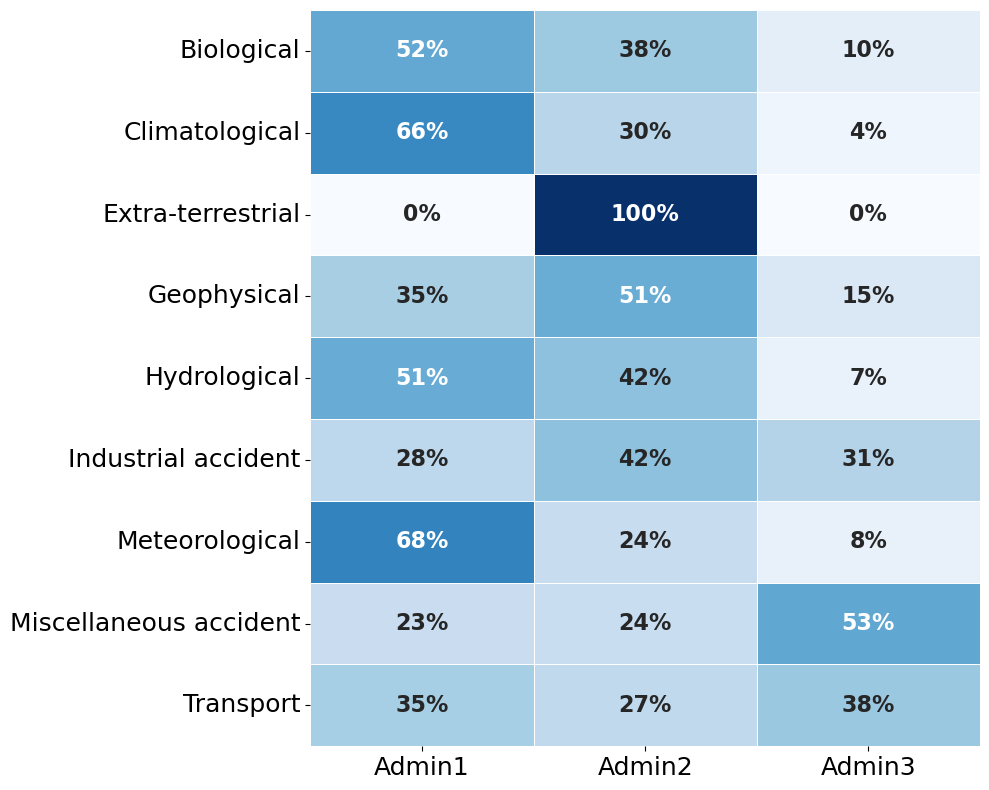

In [29]:
agg_type = df.groupby(['Disaster Subgroup', 'admin_level']).size().reset_index(name='count')
pivot_type = agg_type.pivot(index='Disaster Subgroup', columns='admin_level', values='count').fillna(0)
pivot_pct_type = pivot_type.div(pivot_type.sum(axis=1), axis=0) * 100
pivot_pct_type = pivot_pct_type[['Admin1', 'Admin2', 'Admin3']]
annot_values = pivot_pct_type.round(0).astype(int).astype(str) + "%"

plt.figure(figsize=(10,8))
sns.heatmap(
    pivot_pct_type,
    annot=annot_values,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    annot_kws={"fontsize": 16, "weight": "bold"} 
)

plt.ylabel("")
plt.xlabel("")
plt.xticks(rotation=0, fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()


In [30]:
adm1_emdat = llmgeodis[["DisNo.", "iso3", "admin1", "Disaster Subgroup"]].drop_duplicates()

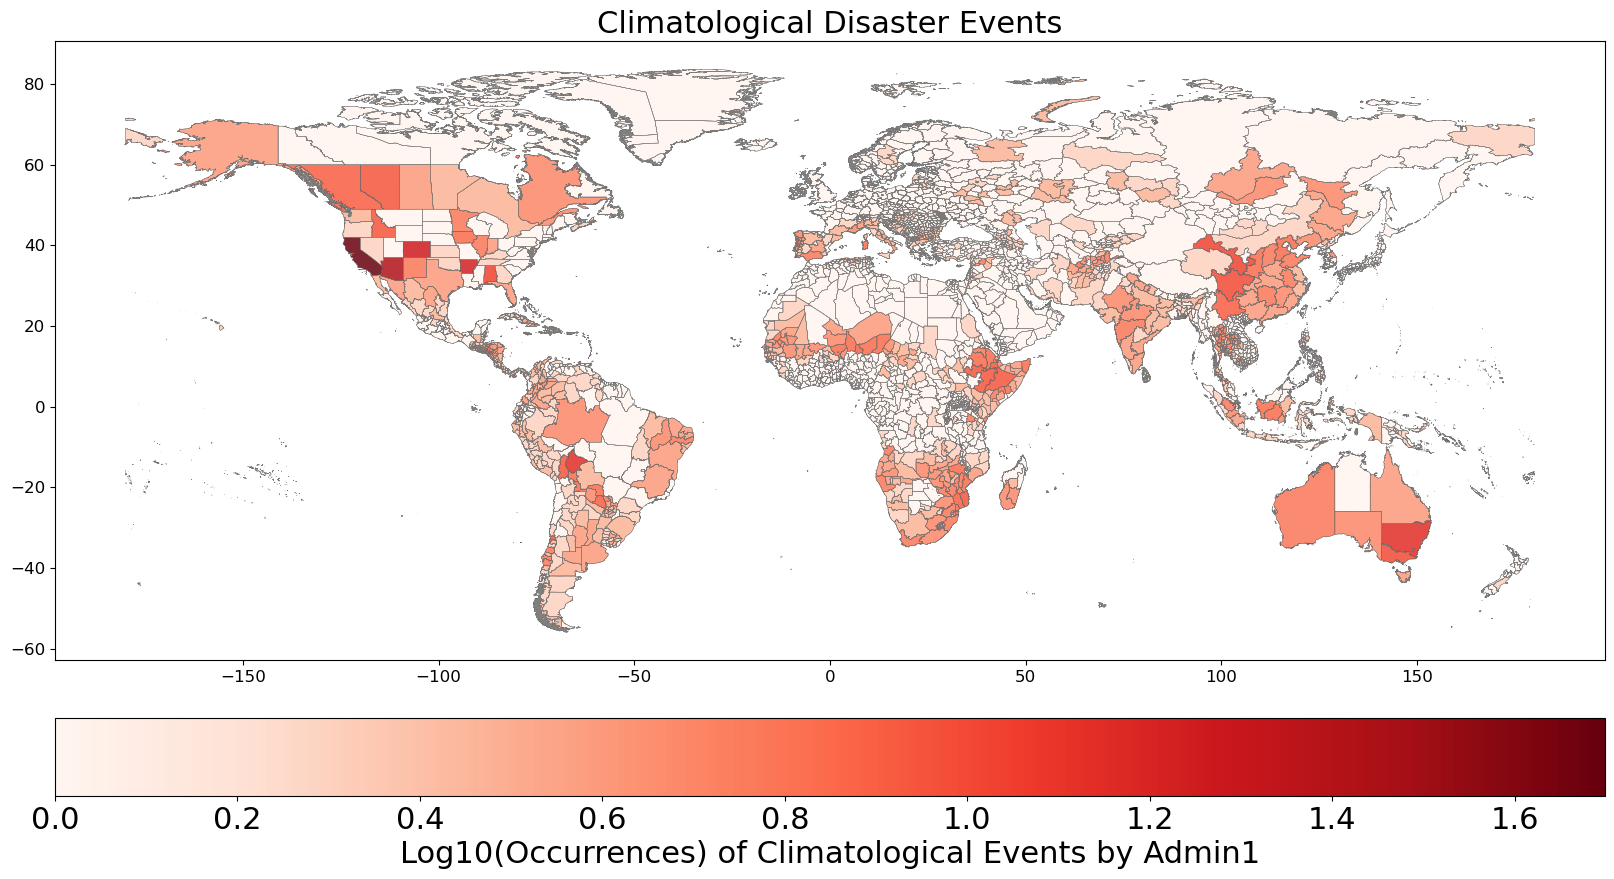

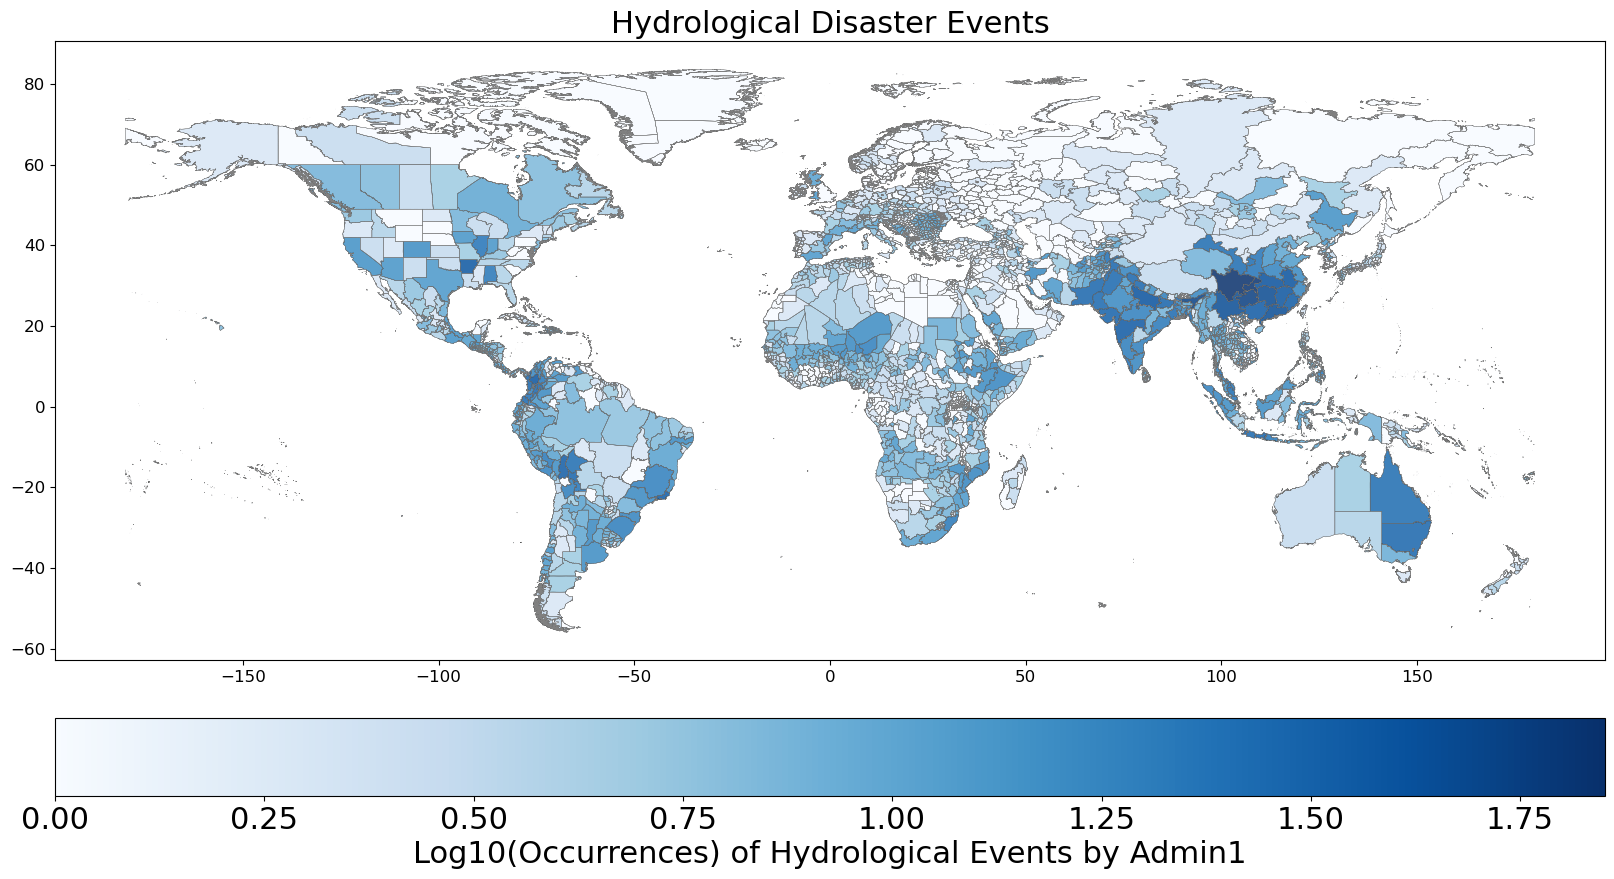

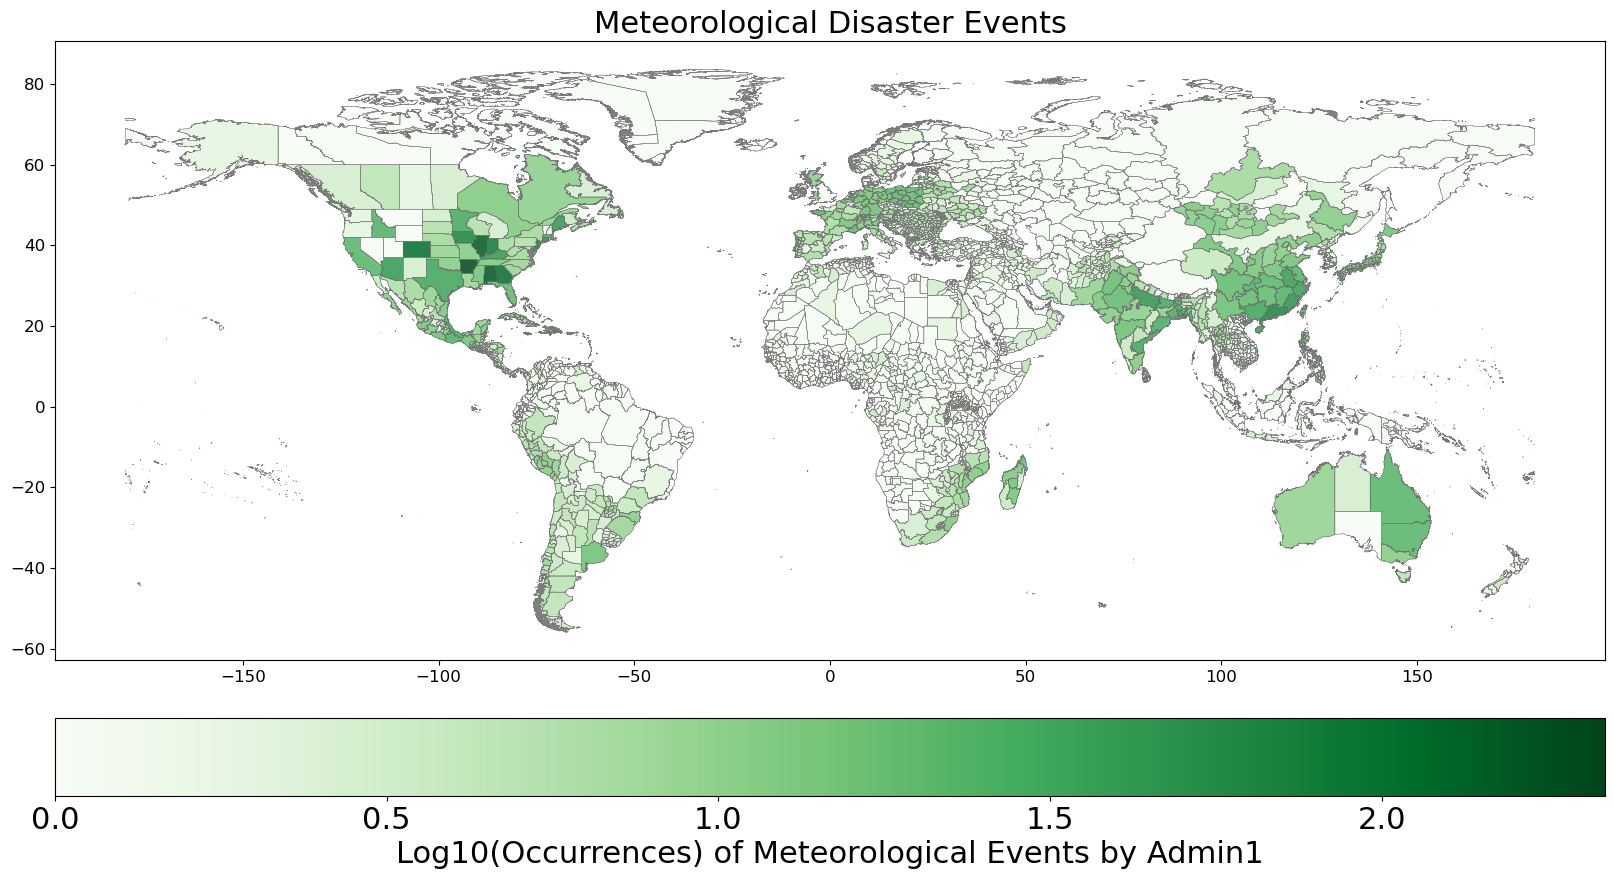

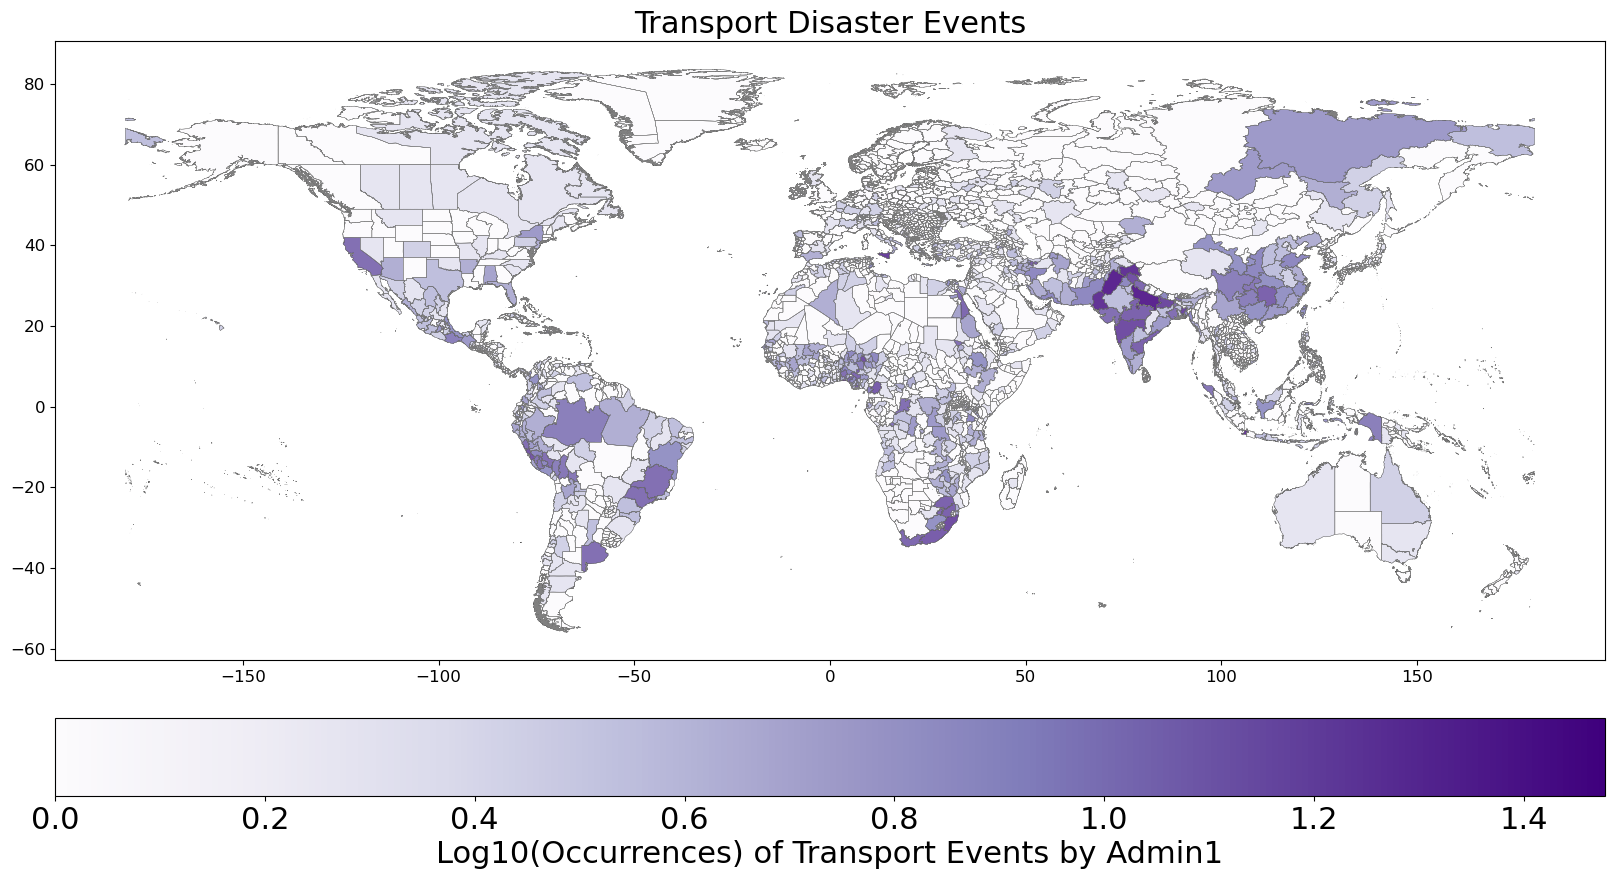

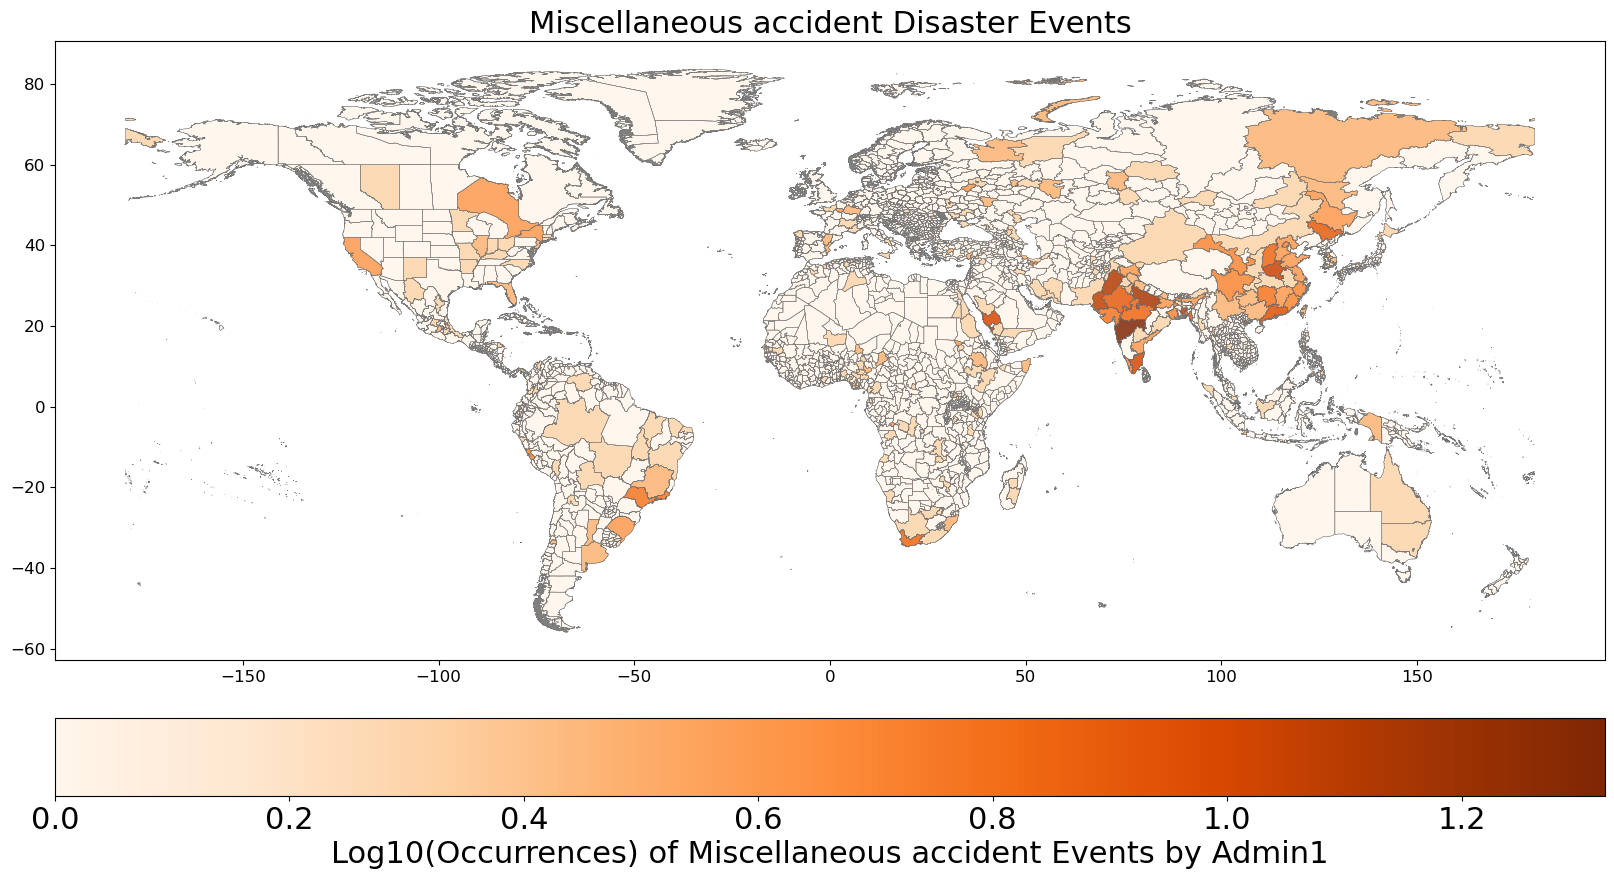

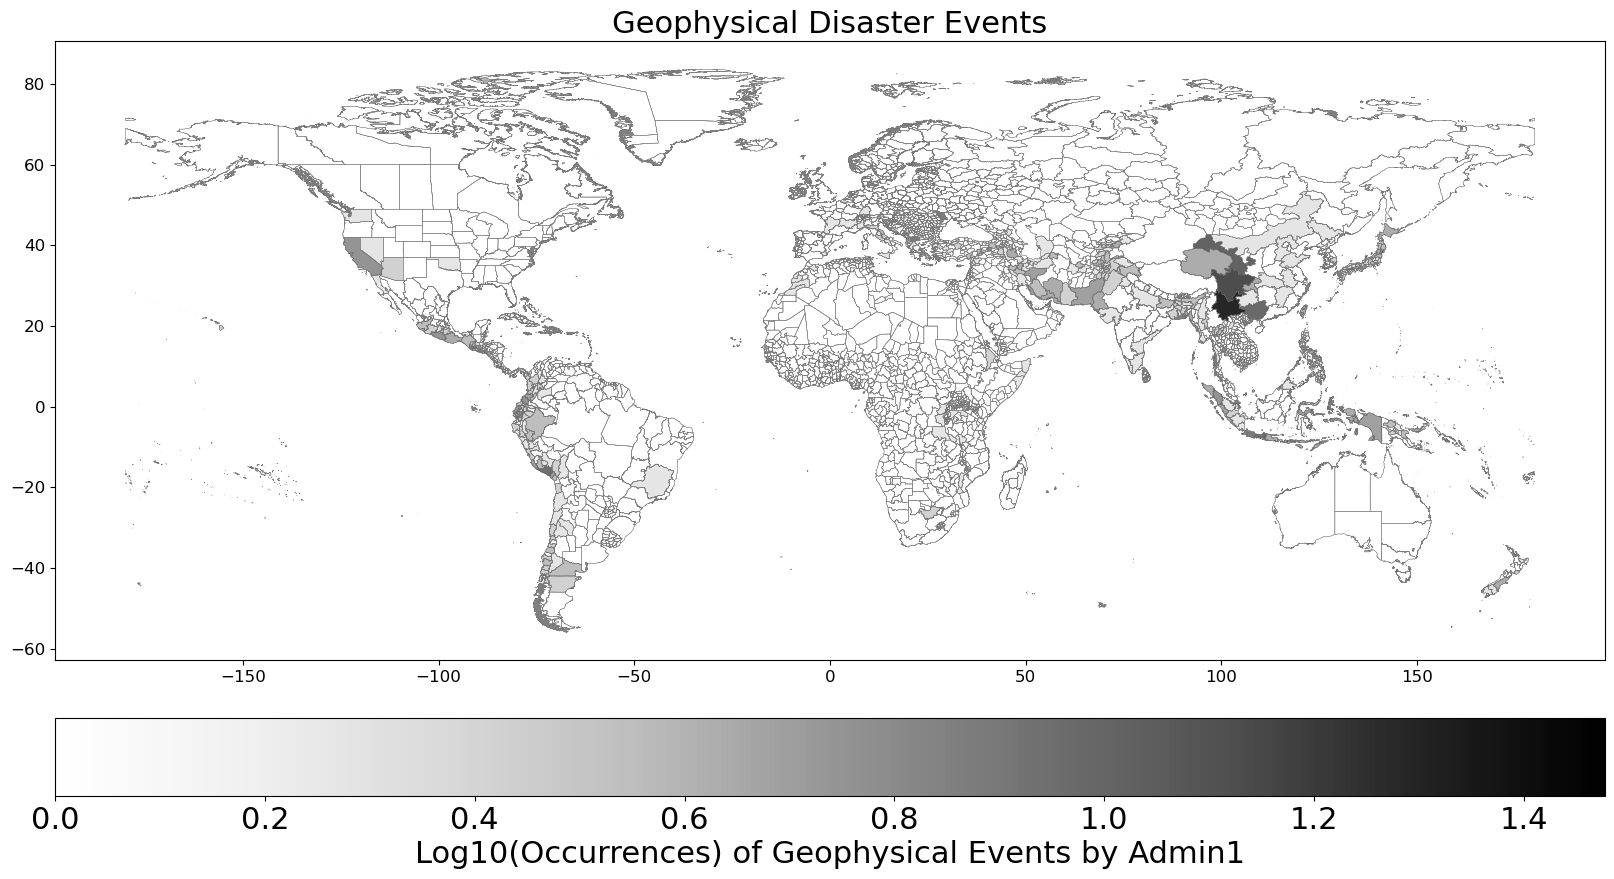

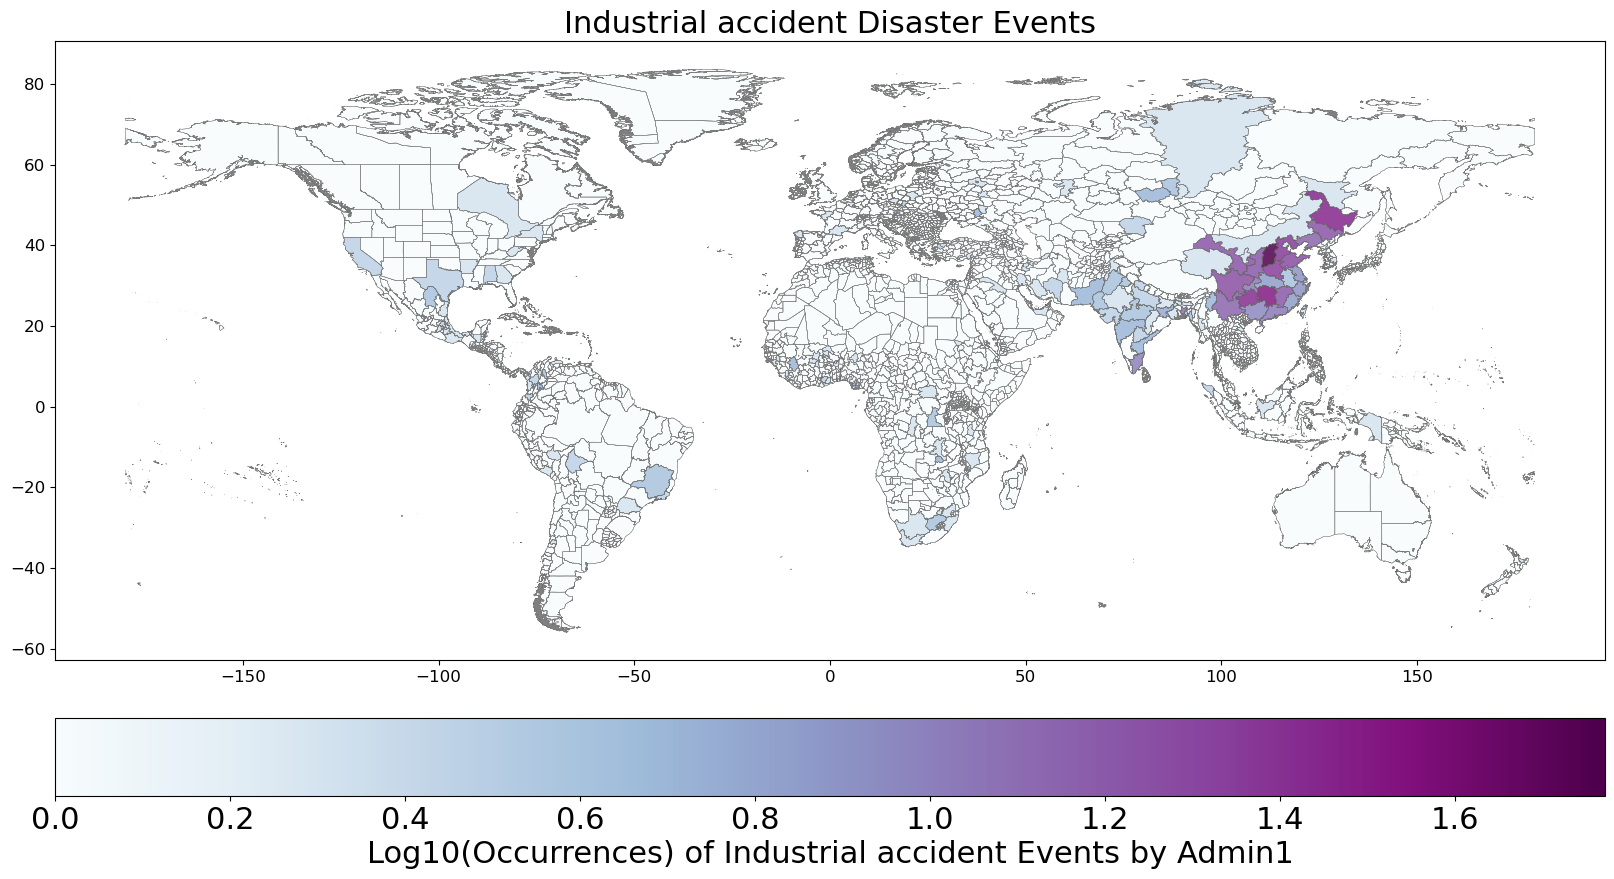

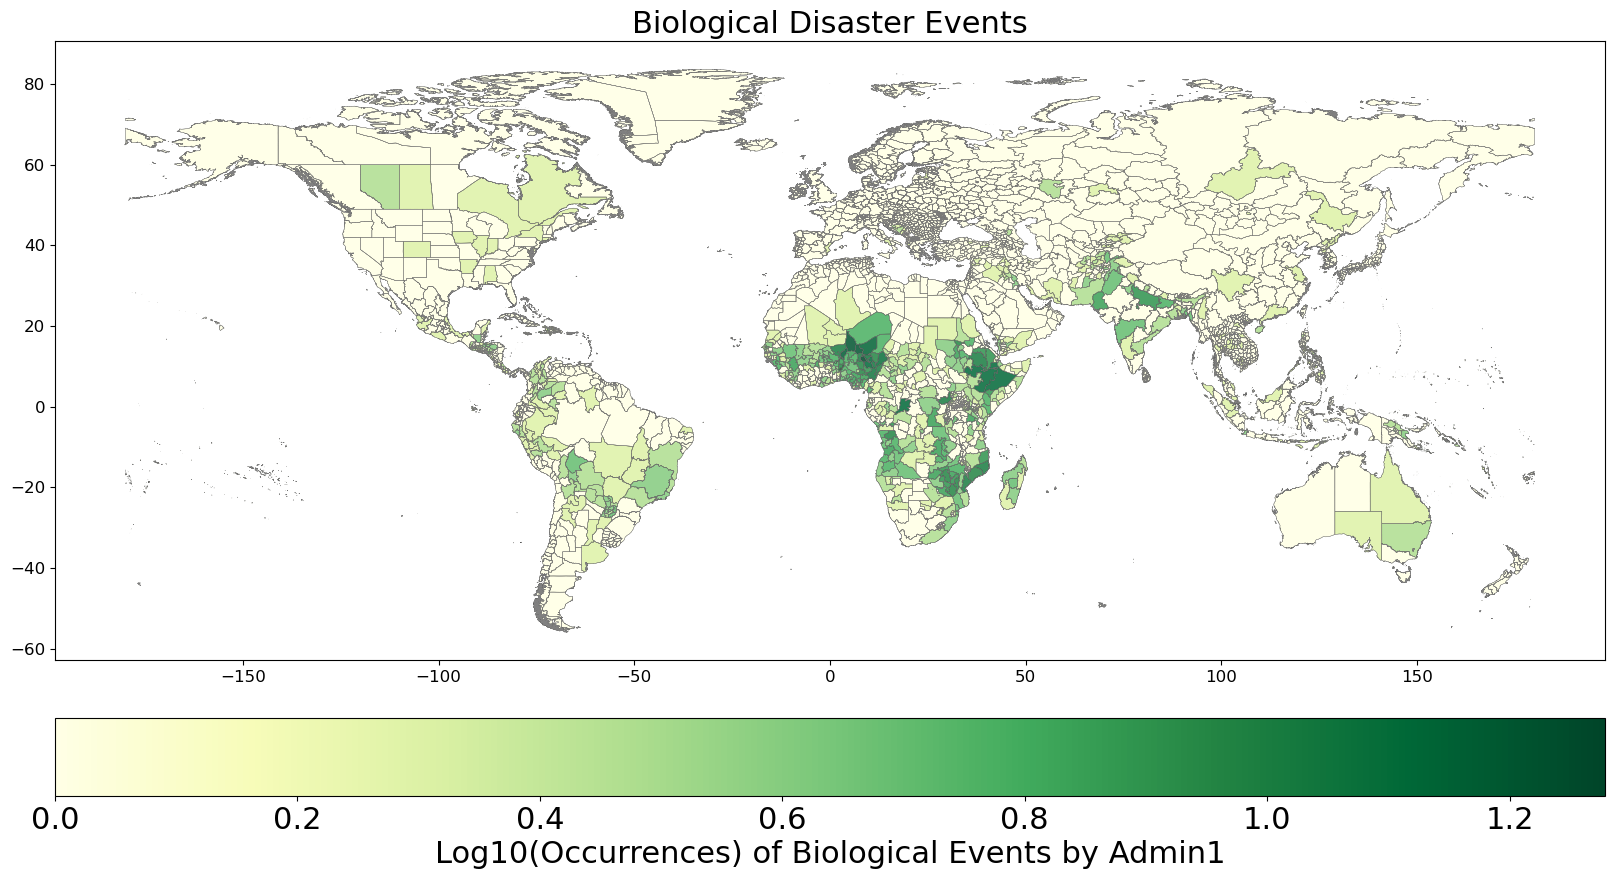

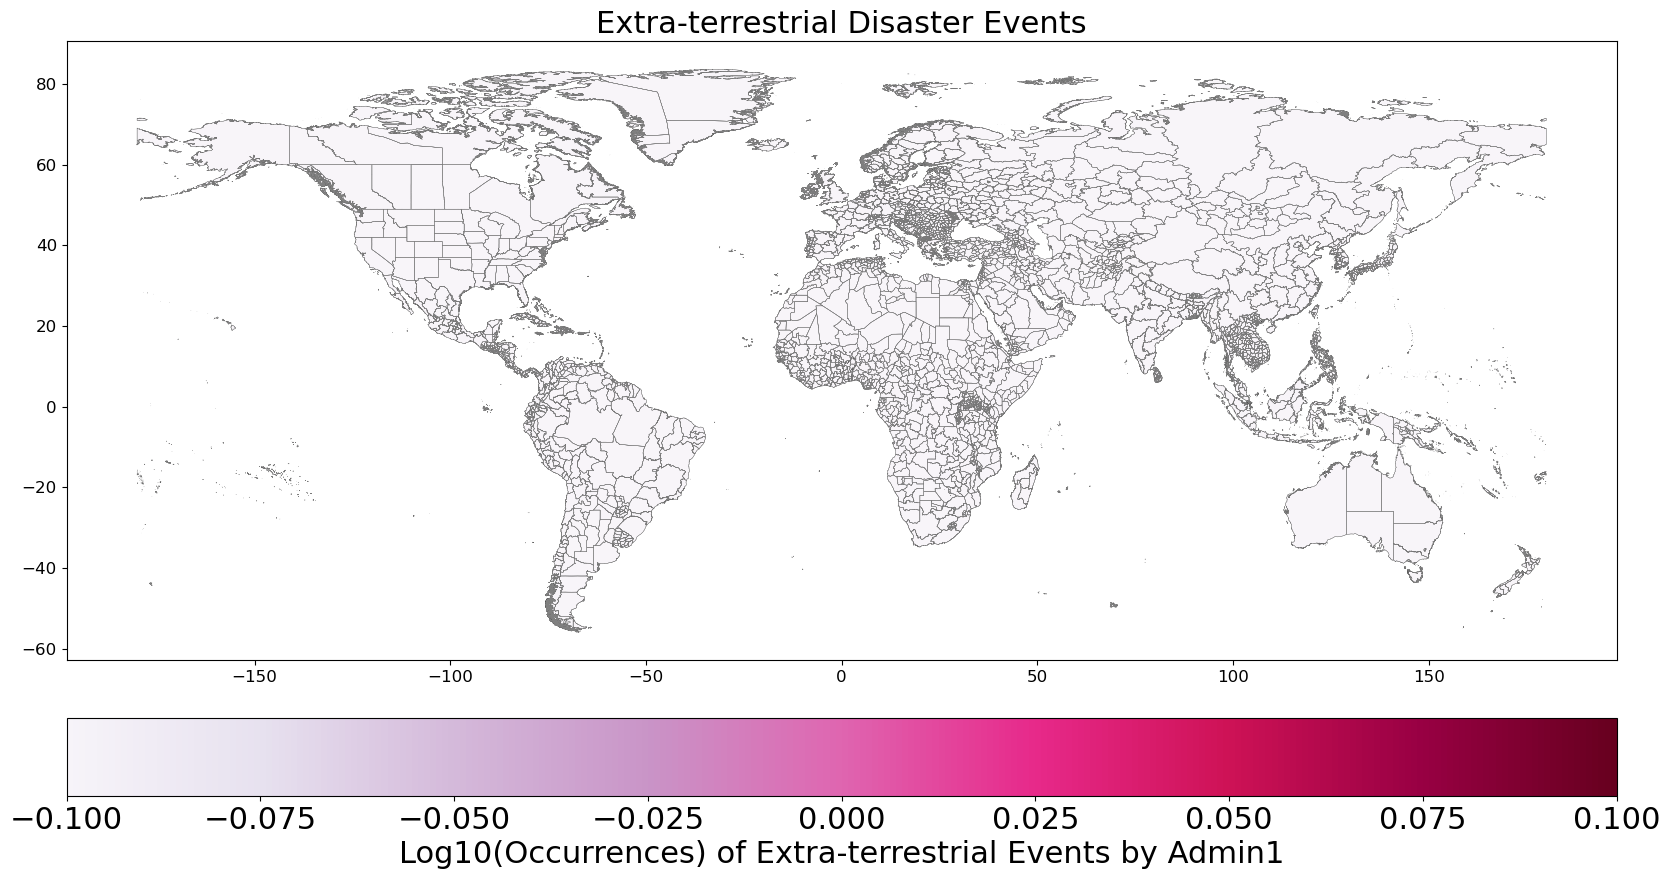

In [35]:

gadm1 = gadm1.rename(columns={"NAME_1":"admin1"})

colormaps = {
    'Climatological': 'Reds',
    'Hydrological': 'Blues',
    'Meteorological': 'Greens',
    'Transport': 'Purples',
    'Miscellaneous accident': 'Oranges',
    'Geophysical': 'Greys',
    'Industrial accident': 'BuPu',
    'Biological': 'YlGn',
    'Extra-terrestrial': 'PuRd'
}

disaster_subgroups = adm1_emdat["Disaster Subgroup"].unique()

for disaster in disaster_subgroups:
    disaster_gdf = adm1_emdat[adm1_emdat['Disaster Subgroup'] == disaster]
    
    occurrence_counts = disaster_gdf.groupby(['iso3', 'admin1']).size().reset_index(name='occurrences')
    occurrence_counts['log_occurrences'] = np.log10(occurrence_counts['occurrences'] + 1)
    
    merged_gdf = gadm1.set_index(['iso3', 'admin1']).join(occurrence_counts.set_index(['iso3', 'admin1'])).fillna(0)

    fig, ax = plt.subplots(1, 1, figsize=(20, 15))

    gadm1.boundary.plot(ax=ax, linewidth=0.2, color='grey')

    cmap = colormaps[disaster]
    merged_gdf.plot(column='log_occurrences', ax=ax, cmap=cmap, alpha=0.85, edgecolor='black', linewidth=0.2)
    
    norm = mcolors.Normalize(vmin=merged_gdf['log_occurrences'].min(), vmax=merged_gdf['log_occurrences'].max())
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label(f'Log10(Occurrences) of {disaster} Events by Admin1', fontsize=22)
    cbar.ax.tick_params(labelsize=22)

    plt.title(f'{disaster} Disaster Events', fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=12)

    plt.show()


In [36]:
unique_disaster_counts = llmgeodis.groupby(['iso3', 'admin1'])['Disaster Type'].nunique().reset_index()
unique_disaster_counts = unique_disaster_counts.rename(columns={'Disaster Type': 'Unique Disaster Types'})



In [43]:
occurrence_counts = llmgeodis.groupby(['iso3', 'admin1']).size().reset_index(name='occurrences')

In [37]:
unique_disaster_counts 

,iso3,admin1,Unique Disaster Types
0,AFG,Badakhshan,8
1,AFG,Badghis,6
2,AFG,Baghlan,8
3,AFG,Balkh,8
4,AFG,Bamyan,6
...,...,...,...
4186,ZWE,Matabeleland,1
4187,ZWE,Matabeleland North,6
4188,ZWE,Matabeleland South,5
4189,ZWE,Midland Province,1


In [49]:
grouped = adm1_emdat.groupby(['iso3','admin1']).size().reset_index(name='occurrences')

In [39]:
grouped_gdf = pd.merge(unique_disaster_counts , gadm1[["iso3", "admin1", "geometry"]], on=["iso3", "admin1"], how="left")

In [40]:
grouped_gdf = gpd.GeoDataFrame(grouped_gdf, geometry="geometry")


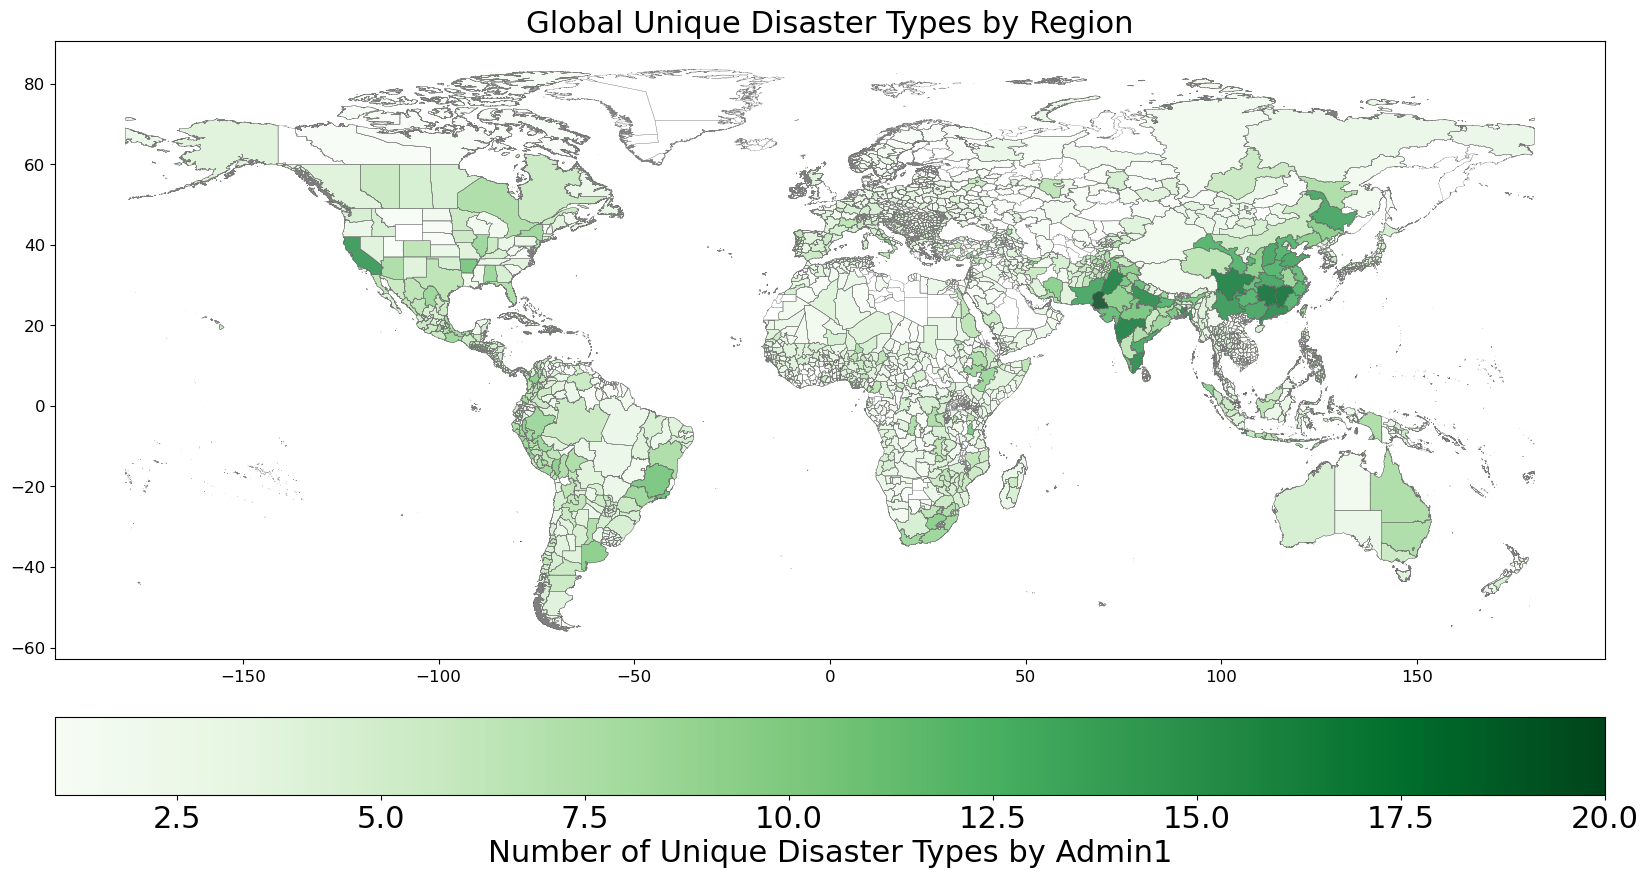

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(20, 15))
gadm1.boundary.plot(ax=ax, linewidth=0.2, color='grey')
cmap = 'Greens'  # You can switch to 'Blues' if preferred
grouped_gdf.plot(column='Unique Disaster Types', ax=ax, cmap=cmap, alpha=0.85, edgecolor='black', linewidth=0.2)

norm = mcolors.Normalize(vmin=grouped_gdf['Unique Disaster Types'].min(), vmax=grouped_gdf['Unique Disaster Types'].max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Number of Unique Disaster Types by Admin1', fontsize=22)
cbar.ax.tick_params(labelsize=22)

plt.title('Global Unique Disaster Types by Region', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()


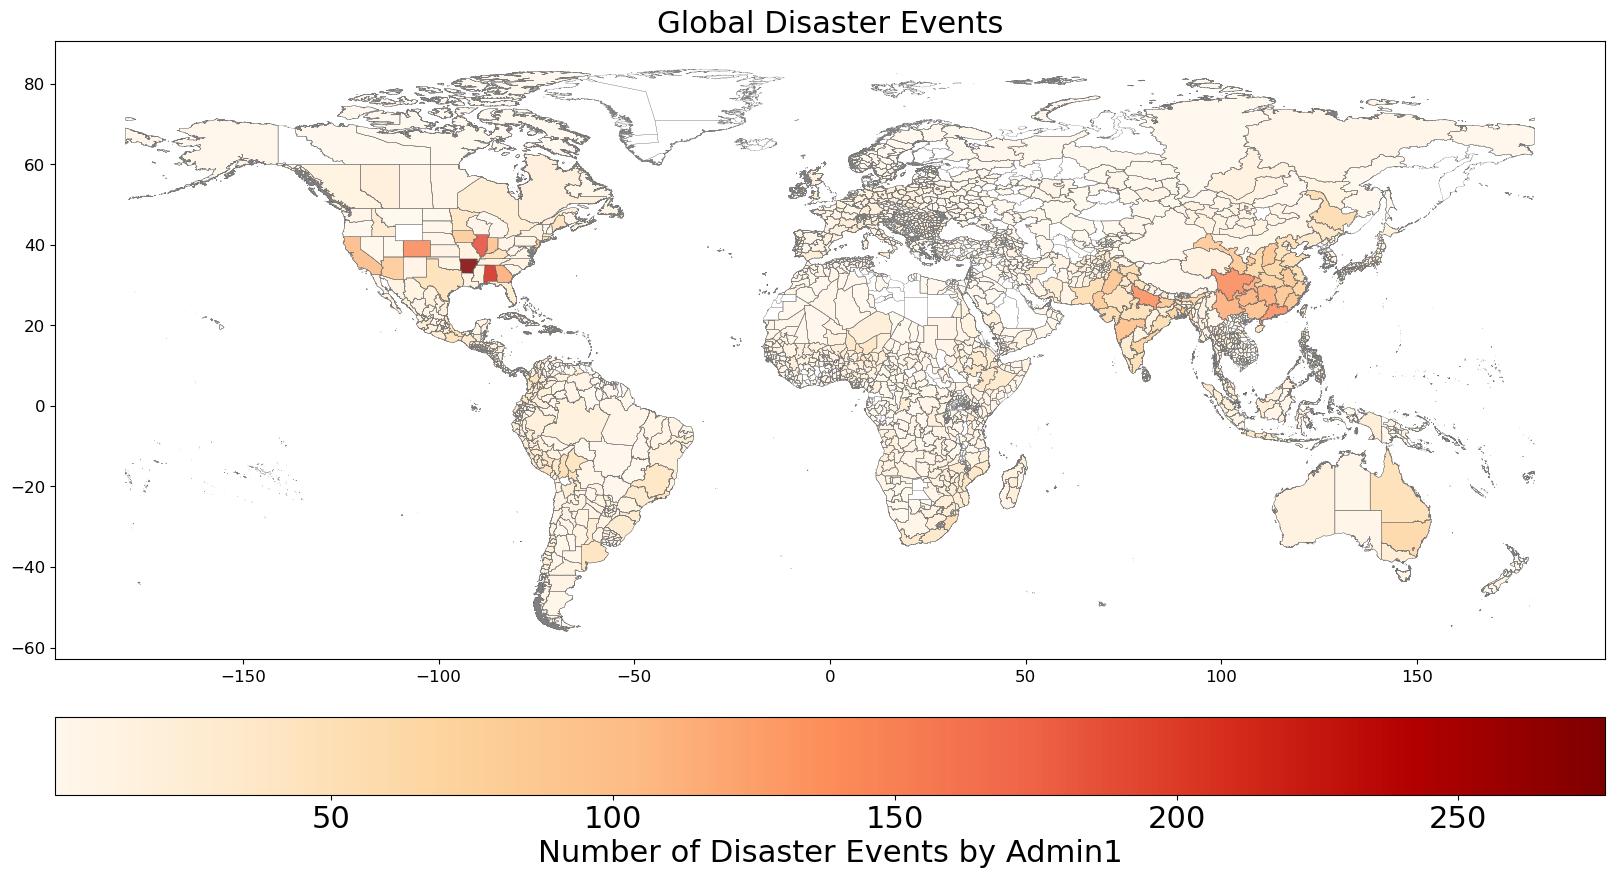

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(20, 15))
gadm1.boundary.plot(ax=ax, linewidth=0.2, color='grey')
cmap = 'OrRd'


grouped_gdf = pd.merge(grouped_gdf, grouped, on=["iso3", "admin1"], how="left")

grouped_gdf.plot(column='occurrences', ax=ax, cmap=cmap, alpha=0.85, edgecolor='black', linewidth=0.2)

norm = mcolors.Normalize(vmin=grouped_gdf['occurrences'].min(), vmax=grouped_gdf['occurrences'].max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Number of Disaster Events by Admin1', fontsize=22)
cbar.ax.tick_params(labelsize=22)
plt.title('Global Disaster Events', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()


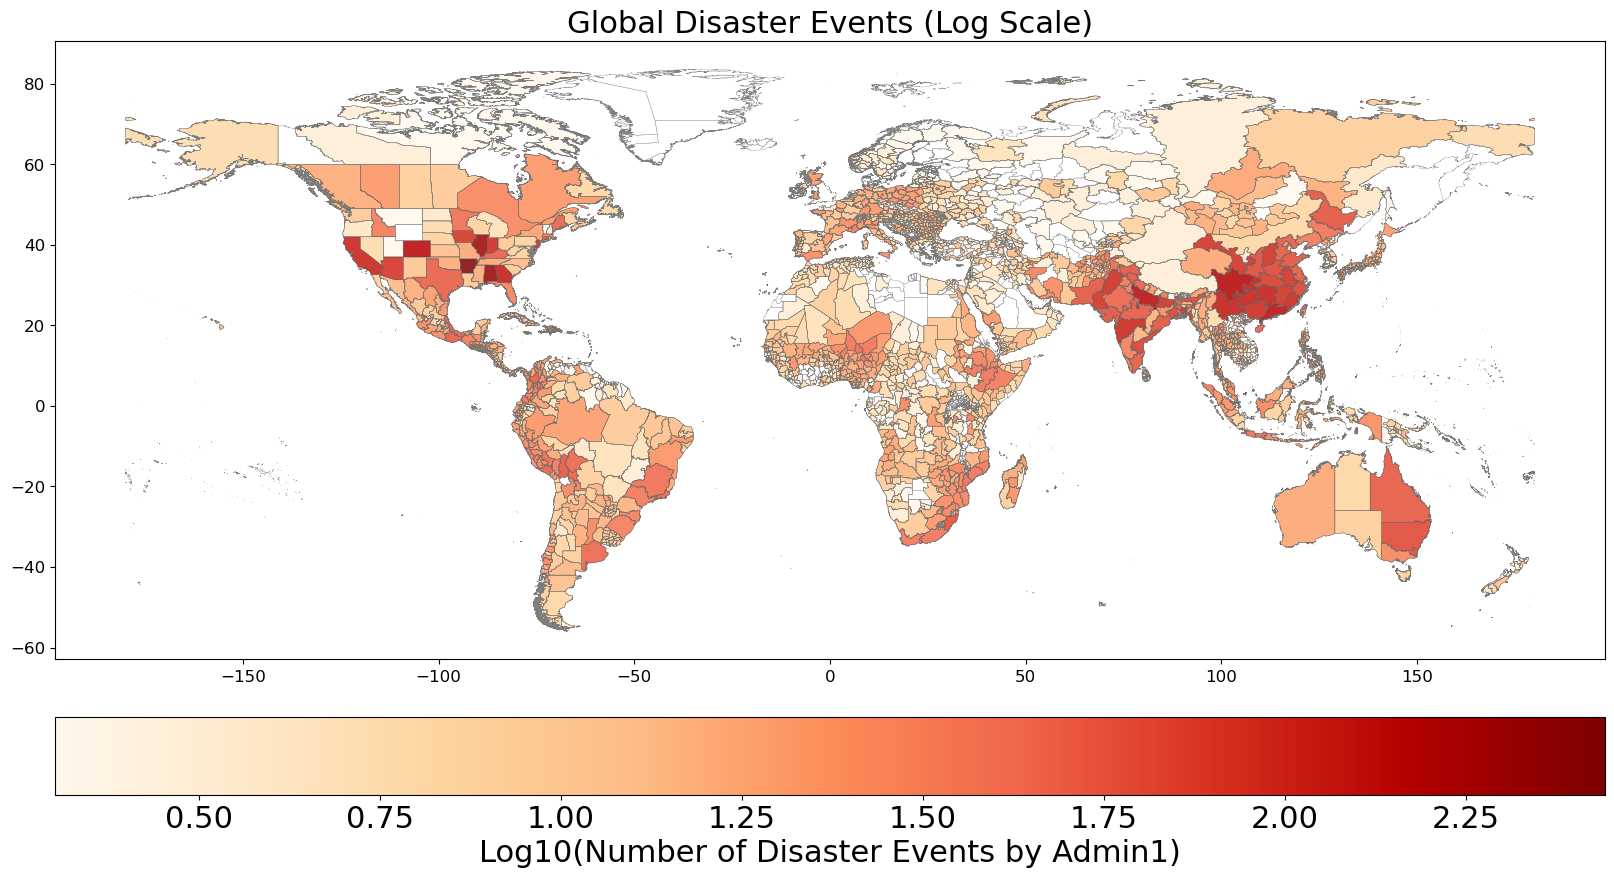

In [53]:
grouped_gdf['log_occurrences'] = np.log10(grouped_gdf['occurrences'] + 1)  
fig, ax = plt.subplots(1, 1, figsize=(20, 15))

gadm1.boundary.plot(ax=ax, linewidth=0.2, color='grey')

cmap = 'OrRd'

grouped_gdf.plot(column='log_occurrences', ax=ax, cmap=cmap, alpha=0.85, edgecolor='black', linewidth=0.2)

norm = mcolors.Normalize(vmin=grouped_gdf['log_occurrences'].min(), vmax=grouped_gdf['log_occurrences'].max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Log10(Number of Disaster Events by Admin1)', fontsize=22)
cbar.ax.tick_params(labelsize=22)
plt.title('Global Disaster Events (Log Scale)', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()
